# FAIR Universe - Weak Lensing ML Uncertainty Challenge
## Phase 2 Starting Kit: Power Spectrum Analysis
***

In the universe, massive objects like galaxies and clusters of galaxies bend the path of light traveling near them — a phenomenon known as gravitational lensing, as predicted by Einstein’s general relativity. When this bending is subtle, it’s known as weak gravitational lensing. It slightly distorts the shapes of distant galaxies as their light travels through the cosmic web of matter, including dark matter and ordinary matter (baryons), on its way to Earth.

By measuring these tiny distortions across the sky, we can reconstruct convergence maps — essentially cosmic “heat maps” that show where matter is concentrated, even if that matter is invisible. These maps let us trace the hidden structure of the universe.

Crucially, weak lensing maps contain rich cosmological information. By statistically analyzing the patterns in these distortions, we can learn about the universe’s content and evolution. For example, we can estimate how much dark matter and dark energy exist, how fast the universe is expanding, and how structures have grown over time. In this way, weak lensing helps us constrain our cosmological model.

So far, the most widely accepted model of the universe is called $\Lambda$CDM (Lambda Cold Dark Matter). It describes a universe dominated by dark energy (represented by the Greek letter $\Lambda$, or Lambda) and cold dark matter, with only a small fraction of normal matter, such as stars and planets. Weak lensing is one of the most powerful tools in cosmology; however, various systematic effects and unknown physics can distort weak lensing maps and introduce uncertainties when estimating parameters of physics models from them. In addition, the real data observed from telescopes could also be different from the detailed setup of our simulation data that is used to train our models. 

The goal of this competition is to identify the weak lensing convergence maps that were generated by unknown systematic effects. The test data is generated assuming different physical models (**out-of-distribution**; **OoD**), and participants' methods should give a continuous OoD score $t(x)$ that increases monotonically with the confidence that their models predict a given sample as OoD.

Participants will not be provided with OoD examples or any information on how the OoD test data are generated. The OoD score $t(x)$ could be, for example, any test statistic increasing monotonically with the OoD likelihood, or the $p$-value defined from the test statistics of the training data and test data. The participants' models will then be scored by a ROC-AUC metric we defined for this competition.

***

`COLAB` determines whether this notebook is running on Google Colab.

In [1]:
COLAB = 'google.colab' in str(get_ipython())

In [2]:
if COLAB:
    # clone github repo
    !git clone --depth 1 https://github.com/FAIR-Universe/Cosmology_Challenge.git
    # move to the HEP starting kit folder
    %cd Cosmology_Challenge/

# 0 - Imports & Settings

In [3]:
import os
import json
import time
import zipfile
import datetime
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import roc_curve

import scipy
from scipy.interpolate import LinearNDInterpolator

# 1 - Helper Classes for
- Utitlity Functions
- Data Loading
- Visualizations
- Scoring Functions

### Utility

In [4]:
class Utility:
    @staticmethod
    def add_noise(data, mask, ng, pixel_size=2.):
        """
        Add noise to a noiseless convergence map.

        Parameters
        ----------
        data : np.array
            Noiseless convergence maps.
        mask : np.array
            Binary mask map.
        ng : float
            Number of galaxies per arcmin². This determines the noise level; a larger number means smaller noise.
        pixel_size : float, optional
            Pixel size in arcminutes (default is 2.0).
        """

        return data + np.random.randn(*data.shape) * 0.4 / (2*ng*pixel_size**2)**0.5 * mask
    
    @staticmethod
    def load_np(data_dir, file_name):
        file_path = os.path.join(data_dir, file_name)
        return np.load(file_path)

    @staticmethod
    def save_np(data_dir, file_name, data):
        file_path = os.path.join(data_dir, file_name)
        np.save(file_path, data)

    @staticmethod
    def save_json_zip(submission_dir, json_file_name, zip_file_name, data):
        """
        Save a dictionary with 'means' and 'errorbars' into a JSON file,
        then compress it into a ZIP file inside submission_dir.

        Parameters
        ----------
        submission_dir : str
            Path to the directory where the ZIP file will be saved.
        file_name : str
            Name of the ZIP file (without extension).
        data : dict
            Dictionary with keys 'means' and 'errorbars'.

        Returns
        -------
        str
            Path to the created ZIP file.
        """
        os.makedirs(submission_dir, exist_ok=True)

        json_path = os.path.join(submission_dir, json_file_name)

        # Save JSON file
        with open(json_path, "w") as f:
            json.dump(data, f)

        # Path to ZIP
        zip_path = os.path.join(submission_dir, zip_file_name)

        # Create ZIP containing only the JSON
        with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
            zf.write(json_path, arcname=json_file_name)

        # Remove the standalone JSON after zipping
        os.remove(json_path)

        return zip_path

### Data

In [ ]:
class Data:
    def __init__(self, data_dir, USE_PUBLIC_DATASET):
        self.USE_PUBLIC_DATASET = USE_PUBLIC_DATASET
        self.data_dir = data_dir
        self.mask_file = 'WIDE12H_bin2_2arcmin_mask.npy'
        self.viz_label_file = 'label_newrealization.npy'
        if self.USE_PUBLIC_DATASET:
            self.kappa_file = 'WIDE12H_bin2_2arcmin_kappa_newrealization.npy'
            self.label_file = self.viz_label_file
            self.Ncosmo = 101  # Number of cosmologies in the entire training data
            self.Nsys = 256    # Number of systematic realizations in the entire training data
            self.test_kappa_file = 'WIDE12H_bin2_2arcmin_kappa_test_phase2_new.npy'
            self.Ntest = 10000  # Number of instances in the test data
        else:
            self.kappa_file = 'sampled_WIDE12H_bin2_2arcmin_kappa.npy'
            self.label_file = 'sampled_label.npy'
            self.Ncosmo = 3    # Number of cosmologies in the sampled training data
            self.Nsys = 30     # Number of systematic realizations in the sampled training data
            self.test_kappa_file = 'sampled_WIDE12H_bin2_2arcmin_kappa_noisy_test.npy'
            self.Ntest = 3     # Number of instances in the sampled test data
        
        self.shape = [1424,176] # dimensions of each map 
        self.pixelsize_arcmin = 2 # pixel size in arcmin
        self.pixelsize_radian = self.pixelsize_arcmin / 60 / 180 * np.pi # pixel size in radian
        self.ng = 30  # galaxy number density. This determines the noise level of the experiment. Do not change this number.

    def load_train_data(self):
        self.mask = Utility.load_np(data_dir=self.data_dir, file_name=self.mask_file) # A binary map that shows which parts of the sky are observed and which areas are blocked
        self.kappa = np.zeros((self.Ncosmo, self.Nsys, *self.shape), dtype=np.float16)
        self.kappa[:,:,self.mask] = Utility.load_np(data_dir=self.data_dir, file_name=self.kappa_file) # Training convergence maps
        self.label = Utility.load_np(data_dir=self.data_dir, file_name=self.label_file) # Training labels (cosmological and physical paramameters) of each training map
        self.viz_label = Utility.load_np(data_dir=self.data_dir, file_name=self.viz_label_file) # For visualization of parameter distributions

    def load_test_data(self):
        self.kappa_test = np.zeros((self.Ntest, *self.shape), dtype=np.float16)
        self.kappa_test[:,self.mask] = Utility.load_np(data_dir=self.data_dir, file_name=self.test_kappa_file) # Test noisy convergence maps

### Visualization

In [6]:
class Visualization:
    
    @staticmethod
    def plot_mask(mask):
        plt.figure(figsize=(30,100))
        plt.imshow(mask.T)
        plt.show()

    @staticmethod
    def plot_noiseless_training_convergence_map(kappa):
        plt.figure(figsize=(30,100))
        plt.imshow(kappa[0,0].T, vmin=-0.02, vmax=0.07)
        plt.show()

    @staticmethod
    def plot_noisy_training_convergence_map(kappa, mask, pixelsize_arcmin, ng):
        plt.figure(figsize=(30,100))
        plt.imshow(Utility.add_noise(kappa[0,0], mask, ng, pixelsize_arcmin).T, vmin=-0.02, vmax=0.07)
        plt.show()

    @staticmethod
    def plot_cosmological_parameters_OmegaM_S8(label):
        plt.scatter(label[:,0,0], label[:,0,1])
        plt.xlabel(r'$\Omega_m$')
        plt.ylabel(r'$S_8$')
        plt.show()

    @staticmethod
    def plot_baryonic_physics_parameters(label):
        plt.scatter(label[0,:,2], label[0,:,3])
        plt.xlabel(r'$T_{\mathrm{AGN}}$')
        plt.ylabel(r'$f_0$')
        plt.show()

    @staticmethod
    def plot_photometric_redshift_uncertainty_parameters(label):
        plt.hist(label[0,:,4], bins=20)
        plt.xlabel(r'$\Delta z$')
        plt.show()

### Scoring function

In [ ]:
class Score:
    @staticmethod
    def _score_phase2(test_labels, ood_scores):
        """
        Computes the ROC-AUC score for Phase 2 based on true InD/OoD labels.

        Parameters
        ----------
        test_labels: np.ndarray
            Array of the ground truths (0=InD, 1=OoD)
        ood_scores: np.ndarray
            Array of continuous test scores that will increase when a sample is more likely to be OoD

        Returns
        -------
        np.ndarray
            ....
        """
        min_fpr = 0.001
        max_fpr = 0.05

        fpr, tpr, thresholds = roc_curve(test_labels, ood_scores)
        fpr_log_interval = np.logspace(np.log10(min_fpr), np.log10(max_fpr), 100)
        tpr_log_interval = np.interp(fpr_log_interval, fpr, tpr)
        score_phase2 = np.mean(tpr_log_interval)
        
        return fpr_log_interval, tpr_log_interval, score_phase2

# 2 - Load train and test data

The training maps are generated by $N_{\rm cosmo}$ cosmological models, each model contains $N_{\rm sys}$ realizations with different nuisance parameters. So the shape of the training maps kappa is $(N_{\rm cosmo}, N_{\rm sys}, 1424, 176)$. 

Each training map is associated with 5 parameters, so the shape of label is $(N_{\rm cosmo}, N_{\rm sys}, 5)$. The first two parameters are cosmological parameters $\Omega_m$ and $S_8$, while the rest three parameters are nuisance parameters that describe systematic effects and need to be marginalized in the data analysis (two of them describe baryonic effects and the last one describes photometric redshift uncertainties).

In [ ]:
root_dir = os.getcwd()
print("Root directory is", root_dir)

**Option 1: To quickly run through this starting kit:** You may set `USE_PUBLIC_DATASET = False` so that only a downsampled training data and test data will be loaded. In the downsampled training data, there are $N_{\rm cosmo}=3$ cosmological models and $N_{\rm sys}=30$ realizations of nuisance parameters. The downsampled test data contains $N_{\rm test}=3$ instances.

***

#### ⚠️ NOTE:
To make a valid submission and obtain a score on Codabench, **you will need to make your predictions using the entire test data set (10,000 instances). Use the Option 2 below to load the entire test data.**

***

**Option 2: To load the entire training data and test data:** Set `USE_PUBLIC_DATASET = True` and specify a path where you will save the downloaded public data from Codabench. In the entire training data, there are $N_{\rm cosmo}=101$ cosmological models and $N_{\rm sys}=256$ realizations of nuisance parameters. The entire test data contains $N_{\rm test}=10000$ instances.

In [ ]:
USE_PUBLIC_DATASET = False

# USE_PUBLIC_DATASET = True
# PUBLIC_DATA_DIR = '[DEFINE THE PATH OF SAVED PUBLIC DATA HERE]'  # This is only required when you set USE_PUBLIC_DATASET = True

In [10]:
if not USE_PUBLIC_DATASET:                                         # Testing this startking kit with a tiny sample of the training data (3, 30, 1424, 176)
    DATA_DIR = os.path.join(root_dir, 'input_data/')
else:                                                              # Training your model with all training data (101, 256, 1424, 176)
    DATA_DIR = PUBLIC_DATA_DIR

### Load the train and test data

In [11]:
# Initialize Data class object
data_obj = Data(data_dir=DATA_DIR, USE_PUBLIC_DATASET=USE_PUBLIC_DATASET)

# Load train data
data_obj.load_train_data()

# Load test data
data_obj.load_test_data()

#### ⚠️ NOTE:
- The original training images are *noiseless* (without any pixel-level noise).
- The original test images is *noisy* (pixel-level noise with galaxy number density $n_g = 30~\text{arcmin}^{-2}$ and pixel size $=2$ arcmin has been added).

- **You will have to add pixel-level noise to the training data through the helper function** `Utility.add_noise`.
    
For example:
```python
    noisy_kappa = Utility.add_noise(data=data_obj.kappa.astype(np.float64), 
                                    mask=data_obj.mask, 
                                    ng=data_obj.ng, 
                                    pixel_size=data_obj.pixelsize_arcmin)
```

The shape of `noisy_kappa` will be the same as the shape of `data_obj.kappa`.

In [12]:
Ncosmo = data_obj.Ncosmo
Nsys = data_obj.Nsys

print(f'There are {Ncosmo} cosmological models, each has {Nsys} realizations of nuisance parameters in the training data.')

There are 101 cosmological models, each has 256 realizations of nuisance parameters in the training data.


In [13]:
print(f'Shape of the training data = {data_obj.kappa.shape}')
print(f'Shape of the mask = {data_obj.mask.shape}')
print(f'Shape of the training label = {data_obj.label.shape}')
print(f'Shape of the test data = {data_obj.kappa_test.shape}')

Shape of the training data = (101, 256, 1424, 176)
Shape of the mask = (1424, 176)
Shape of the training label = (101, 256, 5)
Shape of the test data = (10000, 1424, 176)


# 3 - Visualization

### 2D training maps

survey mask: a binary map that shows which parts of the sky are observed (yellow) and which areas are blocked (purple)

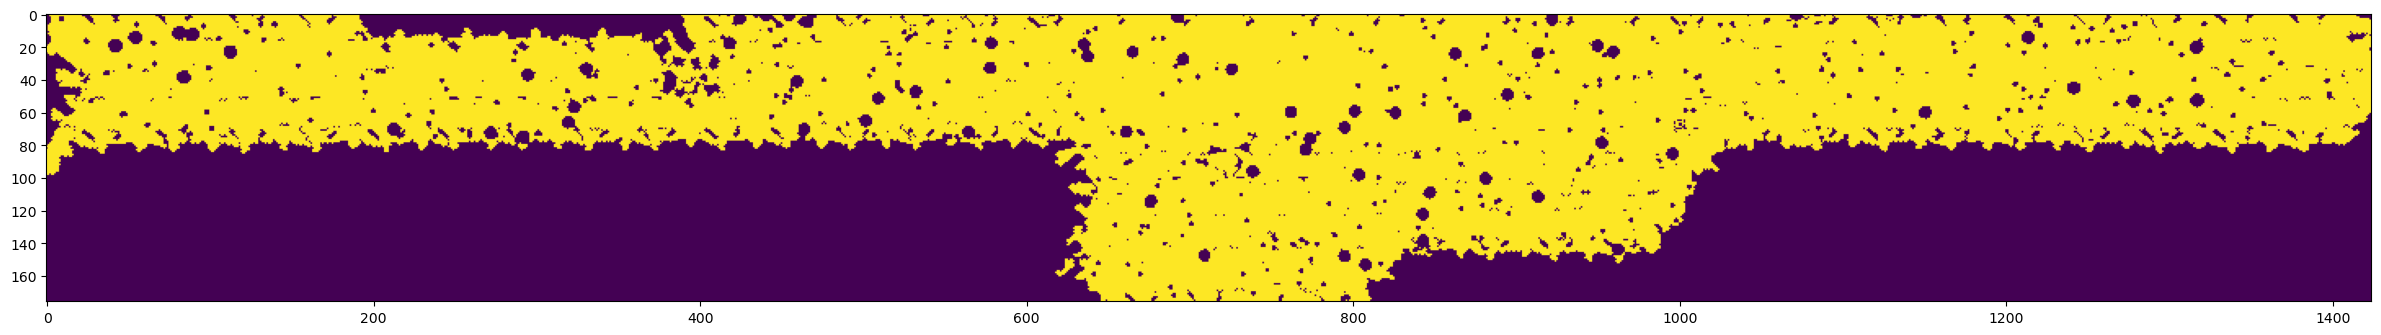

In [14]:
# mask
Visualization.plot_mask(mask=data_obj.mask)

noiseless training convergence map: The convergence maps show the projected matter density (including dark matter and ordinary matter) in the simulated universe, under the Born approximation. On large scales, we can see the matter forms web-like structures (cosmic web) in the universe. The dense regions in these maps, called dark matter halos, are the sites where galaxies form and reside.

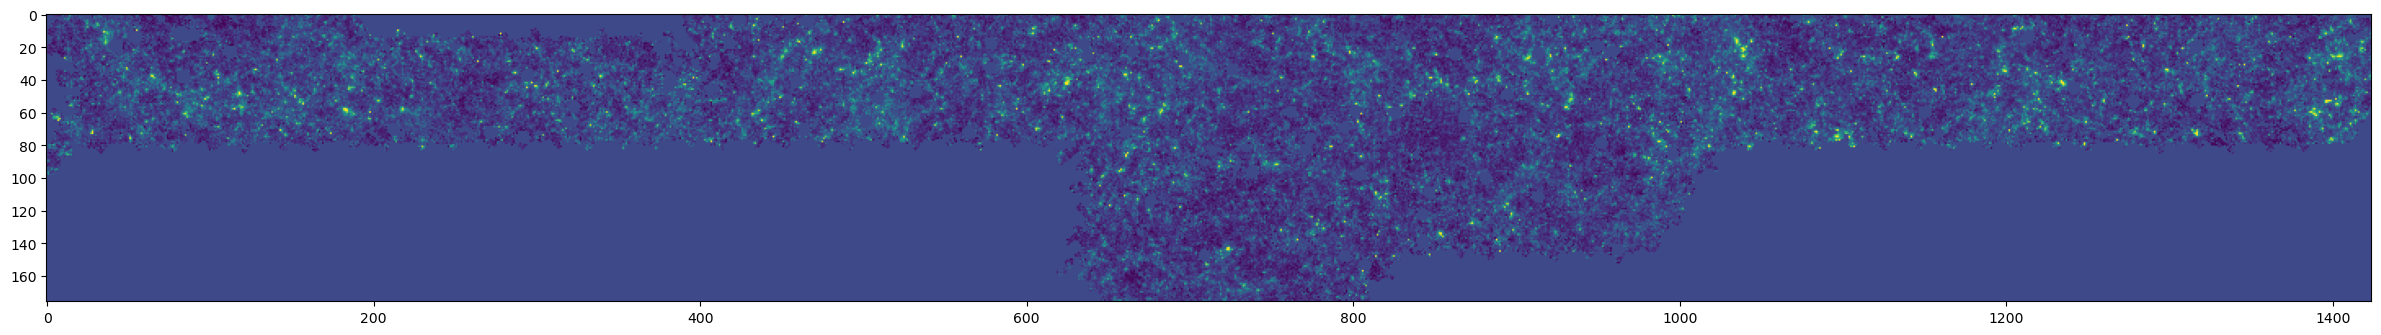

In [15]:
# noiseless training convergence map
Visualization.plot_noiseless_training_convergence_map(kappa=data_obj.kappa)

noisy training convergence map: We add Gaussian noise to the data. This mimics the observed data. During training the noise can be added on the fly with different realizations.

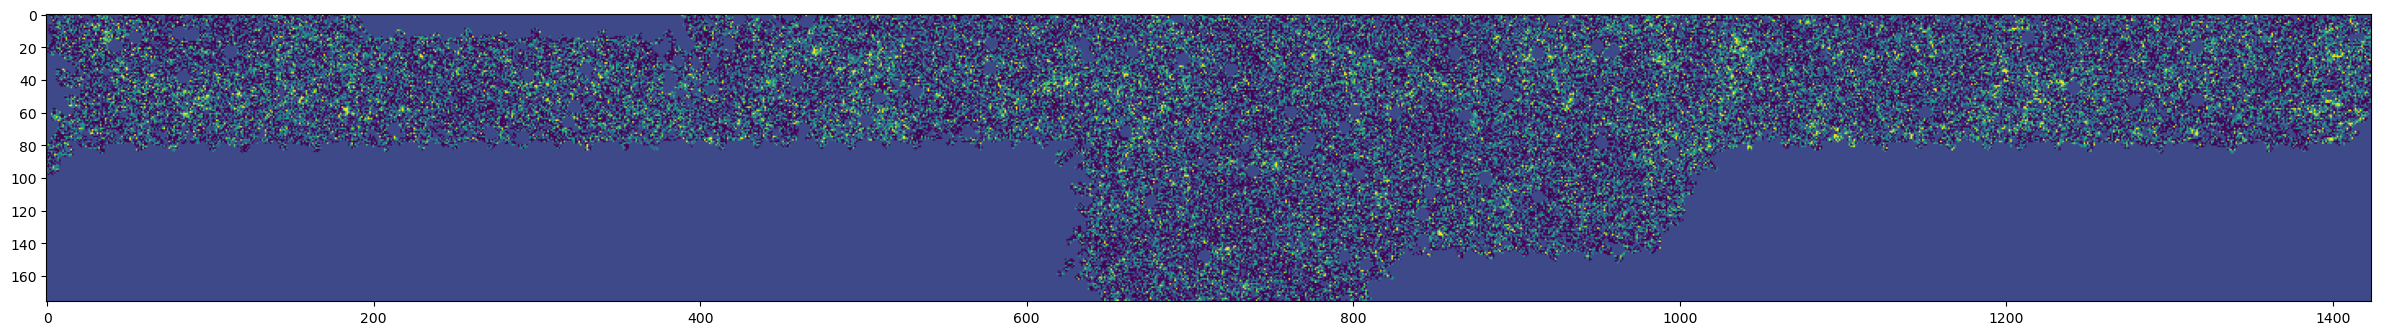

In [16]:
# noisy training convergence map
Visualization.plot_noisy_training_convergence_map(kappa=data_obj.kappa,
                                                  mask=data_obj.mask,
                                                  pixelsize_arcmin=data_obj.pixelsize_arcmin,
                                                  ng=data_obj.ng)

### Distribution of physical parameters

Distribution of cosmological parameters $\Omega_m$ and $S_8$. The density increases towards fiducial cosmology. Note that this distribution introduces a prior in the analysis. The test data cosmology follows the same distribution as the training data.

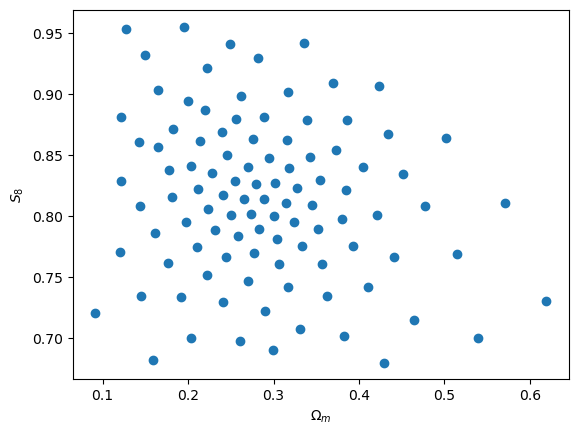

In [31]:
Visualization.plot_cosmological_parameters_OmegaM_S8(label=data_obj.viz_label)

Distribution of baryonic physics parameters. These are nuisance parameters and should be marginalized in the analysis. They follow a uniform distribution within the prior range $T_{\mathrm{AGN}} \in [7.2, 8.5]$, $f_0 \in [0, 0.0265]$

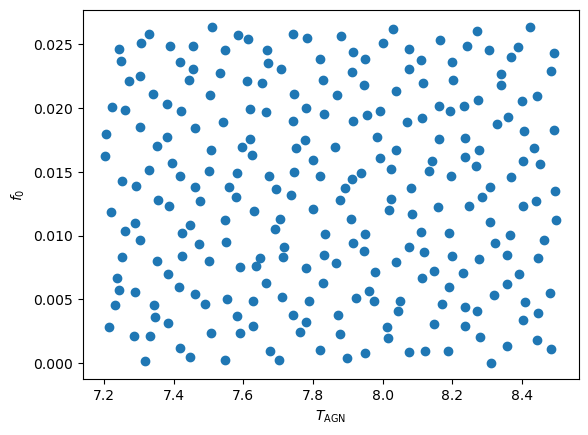

In [32]:
Visualization.plot_baryonic_physics_parameters(label=data_obj.viz_label)

Distribution of photometric redshift uncertainty parameters. This is a nuisance parameter and should be marginalized in the analysis. It follows a Gaussian distribution with mean 0 and std 0.022

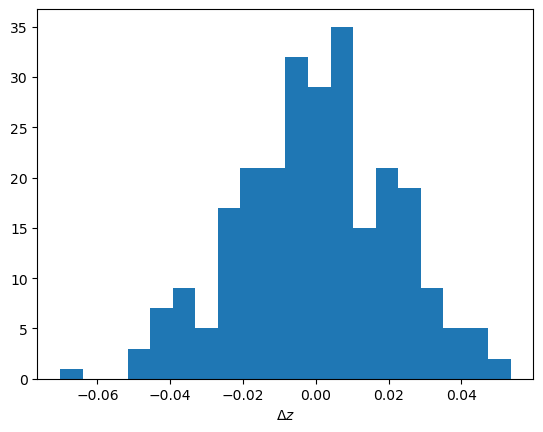

In [20]:
Visualization.plot_photometric_redshift_uncertainty_parameters(label=data_obj.viz_label)

# 4 - Training (build power spectrum and covariance emulator)

In cosmology, the power spectrum describes how matter is distributed across different size scales in the universe and is a key tool for studying the growth of cosmic structure. Starting from the matter density $\delta(x)$, we transform it into Fourier space to get $\tilde{\delta}(x)$, which represents fluctuations as waves of different wavelengths. The matter power spectrum P(k) is then defined by:

\begin{equation}
\langle \tilde{\delta}(\mathbf{k}) \tilde{\delta}^*(\mathbf{k}') \rangle = (2\pi)^3 \delta_D(\mathbf{k}-\mathbf{k}') P(k),
\end{equation}

where k is the wavenumber corresponding to a scale $\lambda \sim 1/k$, and $ \delta_D$ is the Dirac delta function. Intuitively, P(k) tells us how "clumpy" the universe is on different scales. In cosmology, the shape and amplitude of P(k) encodes the physics and composition of the universe, making it one of the most important statistical tools in the field.

In this notebook we use power spectrum as the summary statistic to constrain the cosmological parameters.

In [17]:
Nbins = 10
l_edge = np.logspace(2, 4, Nbins+1)

In [18]:
def power_spectrum(x, pixsize, kedge):
    """
    Compute the azimuthally averaged 2D power spectrum of a real-valued 2D field.

    Parameters:
    -----------
    x : 2D numpy array
        Input real-space map (e.g., an image or simulated field).
        Must be a 2D array with shape (N_y, N_x).
    
    pixsize : float
        Physical size of each pixel in the map (e.g., arcmin, Mpc, etc.).
        Units should be consistent with the units used for `kedge`.
    
    kedge : 1D array-like
        Bin edges in wavenumber space (k), used to bin the power spectrum.
        Should be monotonically increasing and cover the k-range of interest.

    Returns:
    --------
    power_k : 1D numpy array
        The average wavenumber in each k bin (excluding the DC bin).
    
    power : 1D numpy array
        The binned, azimuthally averaged power spectrum corresponding to `power_k`.
        Normalized per unit area.
    """

    # Ensure the input array is 2D
    assert x.ndim == 2

    # Compute the 2D FFT of the input map and take its squared magnitude (power spectrum)
    xk = np.fft.rfft2(x)  # Real-to-complex FFT (along last axis)
    xk2 = (xk * xk.conj()).real  # Power spectrum: |FFT|^2

    # Get the shape of the input map
    Nmesh = x.shape

    # Compute the wavenumber grid (k-space)
    k = np.zeros((Nmesh[0], Nmesh[1]//2+1))
    # Square of the frequency in the first axis
    k += np.fft.fftfreq(Nmesh[0], d=pixsize).reshape(-1, 1) ** 2
    # Square of the frequency in the second axis (real FFT)
    k += np.fft.rfftfreq(Nmesh[1], d=pixsize).reshape(1, -1) ** 2
    # Convert from (1/length)^2 to angular frequency in radian units
    k = k ** 0.5 * 2 * np.pi

    # Bin each k value according to the bin edges provided in kedge
    index = np.searchsorted(kedge, k)

    # Bin the power values, number of modes, and wavenumbers
    power = np.bincount(index.flatten(), weights=xk2.flatten())
    Nmode = np.bincount(index.flatten())
    power_k = np.bincount(index.flatten(), weights=k.flatten())

    # Adjust for symmetry in the real FFT: include the mirrored part (excluding Nyquist frequency)
    if Nmesh[1] % 2 == 0:  # Even number of columns
        power += np.bincount(index[...,1:-1].flatten(), weights=xk2[...,1:-1].flatten())
        Nmode += np.bincount(index[...,1:-1].flatten())
        power_k += np.bincount(index[...,1:-1].flatten(), weights=k[...,1:-1].flatten())
    else:  # Odd number of columns
        power += np.bincount(index[...,1:].flatten(), weights=xk2[...,1:].flatten())
        Nmode += np.bincount(index[...,1:].flatten())
        power_k += np.bincount(index[...,1:].flatten(), weights=k[...,1:].flatten())

    # Exclude the first bin (typically corresponds to DC mode)
    power = power[1:len(kedge)]
    Nmode = Nmode[1:len(kedge)]
    power_k = power_k[1:len(kedge)]

    # Average the power and wavenumber in each bin, only where Nmode > 0
    select = Nmode > 0
    power[select] = power[select] / Nmode[select]
    power_k[select] = power_k[select] / Nmode[select]

    # Normalize the power spectrum by the map area
    power *= pixsize ** 2 / Nmesh[0] / Nmesh[1]

    # Return the binned k values and corresponding power spectrum
    return power_k, power

# 5 - Test statistic for OoD detection

We can obtain the point estimates and their uncertainties by the sampled posterior distribution using MCMC. We have to calculate the mean summary statistics and covariance for $N_{\rm cosmo}$ cosmological models.

The mean summary statistics (descriptors) across the $N$ realizations for each of the $N_{\rm cosmo}$ cosmological models is
$$\mu(\boldsymbol{\theta}) \equiv \left\langle\boldsymbol{d}^{j}\right\rangle =\frac{1}{N} \sum_{j=1}^{N} \boldsymbol{d}^{j}~,$$
where $\boldsymbol{d}^{j}$ is the summary statistics of the $j$-th realizations of a given cosmological model.

The covariance matrix of the summary statistics, used later for parameter inference, is
$$\operatorname{Cov}(\boldsymbol{\theta})=\frac{1}{N-n_d-2} \sum_{j=1}^{N}~[\boldsymbol{d}^{j}-\mu(\boldsymbol{\theta})]^T ~[\boldsymbol{d}^{j}-\mu(\boldsymbol{\theta})],$$
where $n_d$ is the number of summary statistics.

The Gaussian likelihood of an observation (represented by summary statistics $\boldsymbol{d}$ given parameters $\boldsymbol{\theta}$ is:
$$
p(\boldsymbol{d}|\boldsymbol{\theta}) \propto \frac{1}{\sqrt{|{\rm Cov}(\boldsymbol{\theta})|}} \exp \left\{-\frac{1}{2}[\boldsymbol{d}-\mu(\boldsymbol{\theta})]^T {\rm Cov}^{-1}(\boldsymbol{\theta})[\boldsymbol{d}-\mu(\boldsymbol{\theta})]\right\}~.
$$

The log likelihood is thus:
$$
{\rm log}~ p(\boldsymbol{d}|\boldsymbol{\theta}) = -\frac{1}{2}{\rm log}~ |{\rm Cov}(\boldsymbol{\theta})|  -\frac{1}{2}[\boldsymbol{d}-\mu(\boldsymbol{\theta})]^T {\rm Cov}^{-1}(\boldsymbol{\theta})[\boldsymbol{d}-\mu(\boldsymbol{\theta})] + \text{(an offset of the normalization)}~.
$$

In this notebook, we use power spectrum as the summary statistic to constrain the cosmological parameters, so
$$
\boldsymbol{d} = \text{log} ~P(k)~~\text{ with $n_d=$ number of bins in wavenumber } k.
$$

### Calculate the summary statistics $\boldsymbol{d}$ for all maps

In [20]:
# This takes a few minutes
Cl =  np.zeros((Ncosmo, Nsys, Nbins))

for i in range(Ncosmo):
    for j in range(Nsys):
        l, Cl[i,j] = power_spectrum(Utility.add_noise(     # add_noise: Add noise to the noiseless training data
            data=data_obj.kappa[i,j].astype(np.float64), 
            mask=data_obj.mask, 
            ng=data_obj.ng, 
            pixel_size=data_obj.pixelsize_arcmin
        ), data_obj.pixelsize_radian, l_edge)

Utility.save_np(data_dir=DATA_DIR, file_name="allPS.npy", data=Cl)

# Here we use logCl instead of Cl as the summary statistics
logCl = np.log10(Utility.load_np(data_dir=DATA_DIR, file_name="allPS.npy"))

### Mean power spectrum and covariance for $N_{\rm cosmo}$ cosmological model

In [21]:
# mean power spectrum
mean_logCl = np.mean(logCl, 1)
Utility.save_np(data_dir=DATA_DIR, file_name="meanlogPS.npy",data=mean_logCl)

# covariance matrix
delta = (logCl - mean_logCl[:,None])
cov_logCl = [(delta[i].T @ delta[i] / (len(delta[i])-delta.shape[-1]-2))[None] for i in range(Ncosmo)]
cov_logCl = np.concatenate(cov_logCl, 0)
Utility.save_np(data_dir=DATA_DIR, file_name="covlogPS.npy", data=cov_logCl)

### Power spectrum emulator (linear interpolation between $N_{\rm cosmo}$ cosmological models)

In [22]:
# only uses cosmological parameters (the first two parameters) here. The other parameters are nuisance parameters and contain useful information. Here we marginalize the nuisance parameters by ignoring them.
cosmology = data_obj.label[:,0,:2]
mean_logCl = Utility.load_np(data_dir=DATA_DIR, file_name="meanlogPS.npy")
cov_logCl = Utility.load_np(data_dir=DATA_DIR, file_name="covlogPS.npy")

meanlogCl_interp = LinearNDInterpolator(cosmology, mean_logCl, fill_value=np.nan)
covlogCl_interp = LinearNDInterpolator(cosmology, cov_logCl, fill_value=np.nan)

### Define prior, likelihood, posterior

In [23]:
logprior_interp = LinearNDInterpolator(cosmology, np.zeros((Ncosmo, 1)), fill_value=-np.inf)

# Note that the training data are not uniformly sampled, which introduces a prior distribution. Here we ignores that prior for simplicity.
# Also note that this prior would introduce bias for cosmologies at the boundary at the prior
def log_prior(x):
    logprior = logprior_interp(x).flatten()
    return logprior

# Gaussian likelihood with interpolated mean and covariance matrix
def loglike(x, logPS):
    mean = meanlogCl_interp(x)
    cov = covlogCl_interp(x)
    delta = logPS - mean
    
    inv_cov = np.linalg.inv(cov)
    cov_det = np.linalg.slogdet(cov)[1]
    
    return -0.5 * cov_det - 0.5 * np.einsum("ni,nij,nj->n", delta, inv_cov, delta)

def logp_posterior_single(x, logPS):
    # returns log-posterior for a single data
    logp = log_prior(x)
    if np.isfinite(logp):
        return logp + loglike(x, logPS)
    else:
        return logp

def MAP(logCl):
    # returns the Maximum A Posteriori (MAP)
    res = scipy.optimize.minimize(lambda x: -logp_posterior_single(x, logCl), x0=np.array([0.3, 0.8]), method='Nelder-Mead')
    return res.x

def chi2(x, logCl):
    # calculate chi^2 for multiple data
    mean = meanlogCl_interp(x)
    cov = covlogCl_interp(x)
    delta = logCl - mean
    
    inv_cov = np.linalg.inv(cov)
    
    return np.einsum("ni,nij,nj->n", delta, inv_cov, delta)

### Estimate $\chi^2$ for training and test data

Load the power spectrum of training data

In [24]:
Ntrain = Ncosmo*Nsys
logCl_train = logCl.reshape(Ntrain, Nbins)

Find MAP of all training data

In [25]:
MAP_label_train = np.zeros((Ntrain, 2))
for i in range(Ntrain):
    MAP_label_train[i] = MAP(logCl_train[i])
    
Utility.save_np(data_dir=DATA_DIR, file_name="MAP_train.npy", data=MAP_label_train)

Evaluate training data $\chi^2$ at MAP

In [26]:
MAP_label_train = Utility.load_np(data_dir=DATA_DIR, file_name="MAP_train.npy")
chi2_train = chi2(MAP_label_train, logCl_train)

Estimate power spectrum for all test data

In [27]:
test_Cl = np.zeros((data_obj.Ntest, Nbins))

for i in range(data_obj.Ntest):
    l, test_Cl[i] = power_spectrum(data_obj.kappa_test[i].astype(np.float64),
                                   data_obj.pixelsize_radian, l_edge)

Utility.save_np(data_dir=DATA_DIR, file_name="allPS_test.npy", data=test_Cl)

Find MAP

In [28]:
test_Cl = Utility.load_np(data_dir=DATA_DIR, file_name="allPS_test.npy")
test_logCl = np.log10(test_Cl)

In [29]:
MAP_label_test = np.zeros((data_obj.Ntest, 2))
for i in range(data_obj.Ntest):
    MAP_label_test[i] = MAP(test_logCl[i])
    
Utility.save_np(data_dir=DATA_DIR, file_name="MAP_test.npy", data=MAP_label_test)

Evaluate test data $\chi^2$ at MAP

In [30]:
MAP_label_test = Utility.load_np(data_dir=DATA_DIR, file_name="MAP_test.npy")
chi2_test = chi2(MAP_label_test, test_logCl)

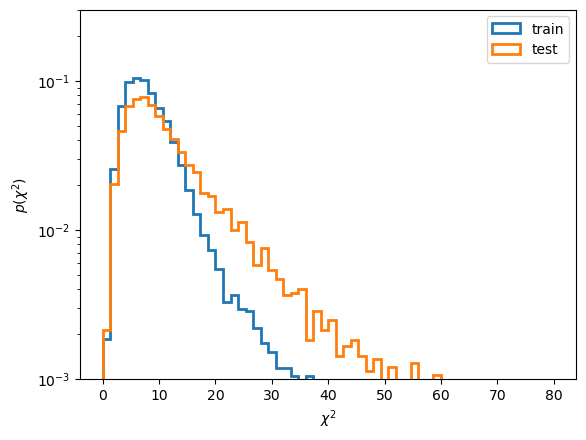

In [34]:
plt.hist(chi2_train, bins = 60, range = (0, 80), density = True, histtype='step', lw = 2, label = 'train')
plt.hist(chi2_test, bins = 60, range = (0, 80), density = True, histtype='step', lw = 2, label = 'test')
plt.xlabel(r'$\chi^2$')
plt.ylabel(r'$p(\chi^2)$')
plt.legend()
plt.ylim(1e-3, 3e-1)
plt.yscale('log')
plt.show()

### Define your OoD score
In this starting kit, we use $\chi^2$ as the test statistic and treat the negative of $p$-values as the OoD score. We add a negative sign so that the score increases when the sample is more likely to be OoD.

In [32]:
## Define the test statistic
TS_InD = chi2_train
TS_test = chi2_test

## Negative of p-values as OoD scores
p_value_test = np.array([np.mean(chi2 < TS_InD) for chi2 in TS_test])
ood_scores = -p_value_test

#### ⚠️ NOTE:
In this starting kit example, you may also directly submit $\chi^2_{\rm test}$ (the test statistics of the test samples) as the OoD scores. However, keep in mind that for other methods, the distribution of the test statistics could be two-sided, which means that OoD samples could be detected by either small or large test statistics. To obtain the best ROC-AUC score, we recommend defining an OoD score that increases monotonically with the OoD probability.

# 6 - Prepare submission for Codabench

***

This section will save the model predictions `ood_scores` (an array with shape `(10000,)`, where `10000` is the number of test instances) as a dictionary in a JSON file `result.json`. Then it will compress `result.json` into a zip file that can be directly submitted to Codabench.

***

In [118]:
data = {"ood_scores": ood_scores.tolist()}
the_date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
zip_file_name = 'Submission_' + the_date + '.zip'
zip_file = Utility.save_json_zip(
    submission_dir="submissions",
    json_file_name="result.json",
    zip_file_name=zip_file_name,
    data=data
)
print(f"Submission ZIP saved at: {zip_file}")

Submission ZIP saved at: submissions/Submission_26-03-10-17-27.zip
